## Goal

The goal of this notebook is to **explore and understand** the agricultural 
irrigation dataset through visual and statistical analysis.

We aim to answer:

- How are the features distributed?
- Are any features correlated with each other?
- Which features show the strongest relationship with Irrigation Need?
- Is the target class balanced?
- Is the data clean — any outliers, nulls or anomalies?


## Importing data:

In [1]:
import pandas as pd

path = '/kaggle/input/competitions/playground-series-s6e4/'

train_df = pd.read_csv(path + 'train.csv')
display(train_df.head(5))
print('Training set: ', train_df.shape)

test_df = pd.read_csv(path + 'test.csv')
display(test_df.head(5))
print('Test set: ', test_df.shape)

,id,Soil_Type,Soil_pH,Soil_Moisture,Organic_Carbon,Electrical_Conductivity,Temperature_C,Humidity,Rainfall_mm,Sunlight_Hours,...,Crop_Type,Crop_Growth_Stage,Season,Irrigation_Type,Water_Source,Field_Area_hectare,Mulching_Used,Previous_Irrigation_mm,Region,Irrigation_Need
0,0,Loamy,4.92,32.58,1.01,3.05,15.01,50.61,725.99,5.90,...,Sugarcane,Sowing,Zaid,Drip,Rainwater,0.82,No,112.16,East,Low
1,1,Clay,7.08,56.61,0.44,2.00,22.92,67.86,985.66,6.98,...,Wheat,Vegetative,Kharif,Rainfed,River,5.27,Yes,47.16,South,Low
2,2,Clay,5.69,27.71,0.81,2.83,26.97,92.22,2201.70,6.05,...,Rice,Vegetative,Kharif,Sprinkler,Reservoir,8.24,Yes,110.38,North,Low
3,3,Sandy,5.65,13.32,1.33,0.87,13.32,61.57,1357.33,9.12,...,Wheat,Flowering,Kharif,Canal,River,8.32,Yes,53.85,South,Medium
4,4,Clay,7.96,59.14,0.38,0.96,20.22,91.11,1538.20,6.95,...,Wheat,Sowing,Rabi,Canal,River,7.37,No,93.19,South,Low


Training set:  (630000, 21)


,id,Soil_Type,Soil_pH,Soil_Moisture,Organic_Carbon,Electrical_Conductivity,Temperature_C,Humidity,Rainfall_mm,Sunlight_Hours,Wind_Speed_kmh,Crop_Type,Crop_Growth_Stage,Season,Irrigation_Type,Water_Source,Field_Area_hectare,Mulching_Used,Previous_Irrigation_mm,Region
0,630000,Silt,6.36,26.19,0.59,2.81,17.83,30.24,1533.38,5.40,3.00,Maize,Sowing,Rabi,Canal,River,13.59,Yes,47.48,West
1,630001,Clay,5.87,9.88,1.18,3.26,21.18,78.07,576.05,7.22,15.88,Cotton,Sowing,Rabi,Drip,Reservoir,6.12,Yes,56.43,South
2,630002,Sandy,6.22,26.55,0.96,0.85,26.87,60.35,545.30,9.43,2.63,Wheat,Sowing,Kharif,Sprinkler,Reservoir,3.11,Yes,20.00,East
3,630003,Clay,7.68,53.58,0.83,0.55,41.74,36.05,1211.03,6.69,1.86,Maize,Harvest,Rabi,Canal,Groundwater,2.27,No,102.99,North
4,630004,Loamy,5.23,59.02,0.54,2.11,41.08,52.47,1321.91,4.11,5.71,Cotton,Sowing,Kharif,Canal,Groundwater,12.39,Yes,13.33,Central


Test set:  (270000, 20)


In [2]:
#checking what columns are available
train_df.info()

#checking for null values:
print(train_df.isna().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 630000 entries, 0 to 629999
Data columns (total 21 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   id                       630000 non-null  int64  
 1   Soil_Type                630000 non-null  object 
 2   Soil_pH                  630000 non-null  float64
 3   Soil_Moisture            630000 non-null  float64
 4   Organic_Carbon           630000 non-null  float64
 5   Electrical_Conductivity  630000 non-null  float64
 6   Temperature_C            630000 non-null  float64
 7   Humidity                 630000 non-null  float64
 8   Rainfall_mm              630000 non-null  float64
 9   Sunlight_Hours           630000 non-null  float64
 10  Wind_Speed_kmh           630000 non-null  float64
 11  Crop_Type                630000 non-null  object 
 12  Crop_Growth_Stage        630000 non-null  object 
 13  Season                   630000 non-null  object 
 14  Irri

What we observe is that there are 20 columns, out of which 'id' is redundant and 'Irrigation_Need' = target so we have 18 features to work with. 
Feature Dtype counts:
* float64 = 11
* int64 = 1; id
* object = 9; 8 + 1(target)

Also there are no null values present.

In [3]:
#initiating target variable
target = 'Irrigation_Need'
X = train_df.drop(columns=['id',target], axis=1)
y= train_df[target]

In [4]:
X.describe()

,Soil_pH,Soil_Moisture,Organic_Carbon,Electrical_Conductivity,Temperature_C,Humidity,Rainfall_mm,Sunlight_Hours,Wind_Speed_kmh,Field_Area_hectare,Previous_Irrigation_mm
count,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000
mean,6.482497,37.304482,0.922858,1.744605,26.998166,61.563180,1462.207566,7.513382,10.375394,7.517745,62.318177
std,0.922504,16.377082,0.365808,0.952321,8.623621,19.708152,612.989738,1.999322,5.689458,4.218124,34.246939
min,4.800000,8.000000,0.300000,0.100000,12.000000,25.000000,0.380000,4.000000,0.500000,0.300000,0.020000
25%,5.690000,23.340000,0.610000,0.930000,19.517500,45.390000,954.570000,5.760000,5.280000,3.880000,33.140000
50%,6.440000,37.750000,0.910000,1.740000,26.960000,61.650000,1467.160000,7.580000,10.480000,7.380000,61.150000
75%,7.270000,51.270000,1.220000,2.580000,34.540000,79.120000,2054.280000,9.250000,15.430000,11.140000,92.690000
max,8.200000,64.990000,1.600000,3.500000,42.000000,94.990000,2499.690000,11.000000,20.000000,15.000000,119.990000


## Taraget Distribution:

dict_items([('Low', 369917), ('Medium', 239074), ('High', 21009)])


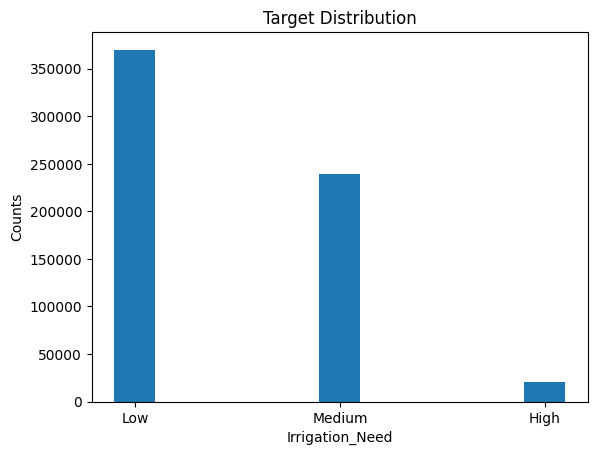

In [5]:
import matplotlib.pyplot as plt
from collections import Counter

target_counts = Counter(y)
print(target_counts.items())

plt.bar(target_counts.keys(), target_counts.values(), width=0.2)
plt.xlabel('Irrigation_Need')
plt.ylabel('Counts')
plt.title('Target Distribution')
plt.show()

Target is highly imbalanced, we will have to be careful while training the model and make sure bias isnt introduced

In [6]:
#Separating numerical and categorical features:
num_cols = X.select_dtypes(include='number').columns
cat_cols = X.select_dtypes(include='object').columns

## Numerical feature analysis:

### Distributions:

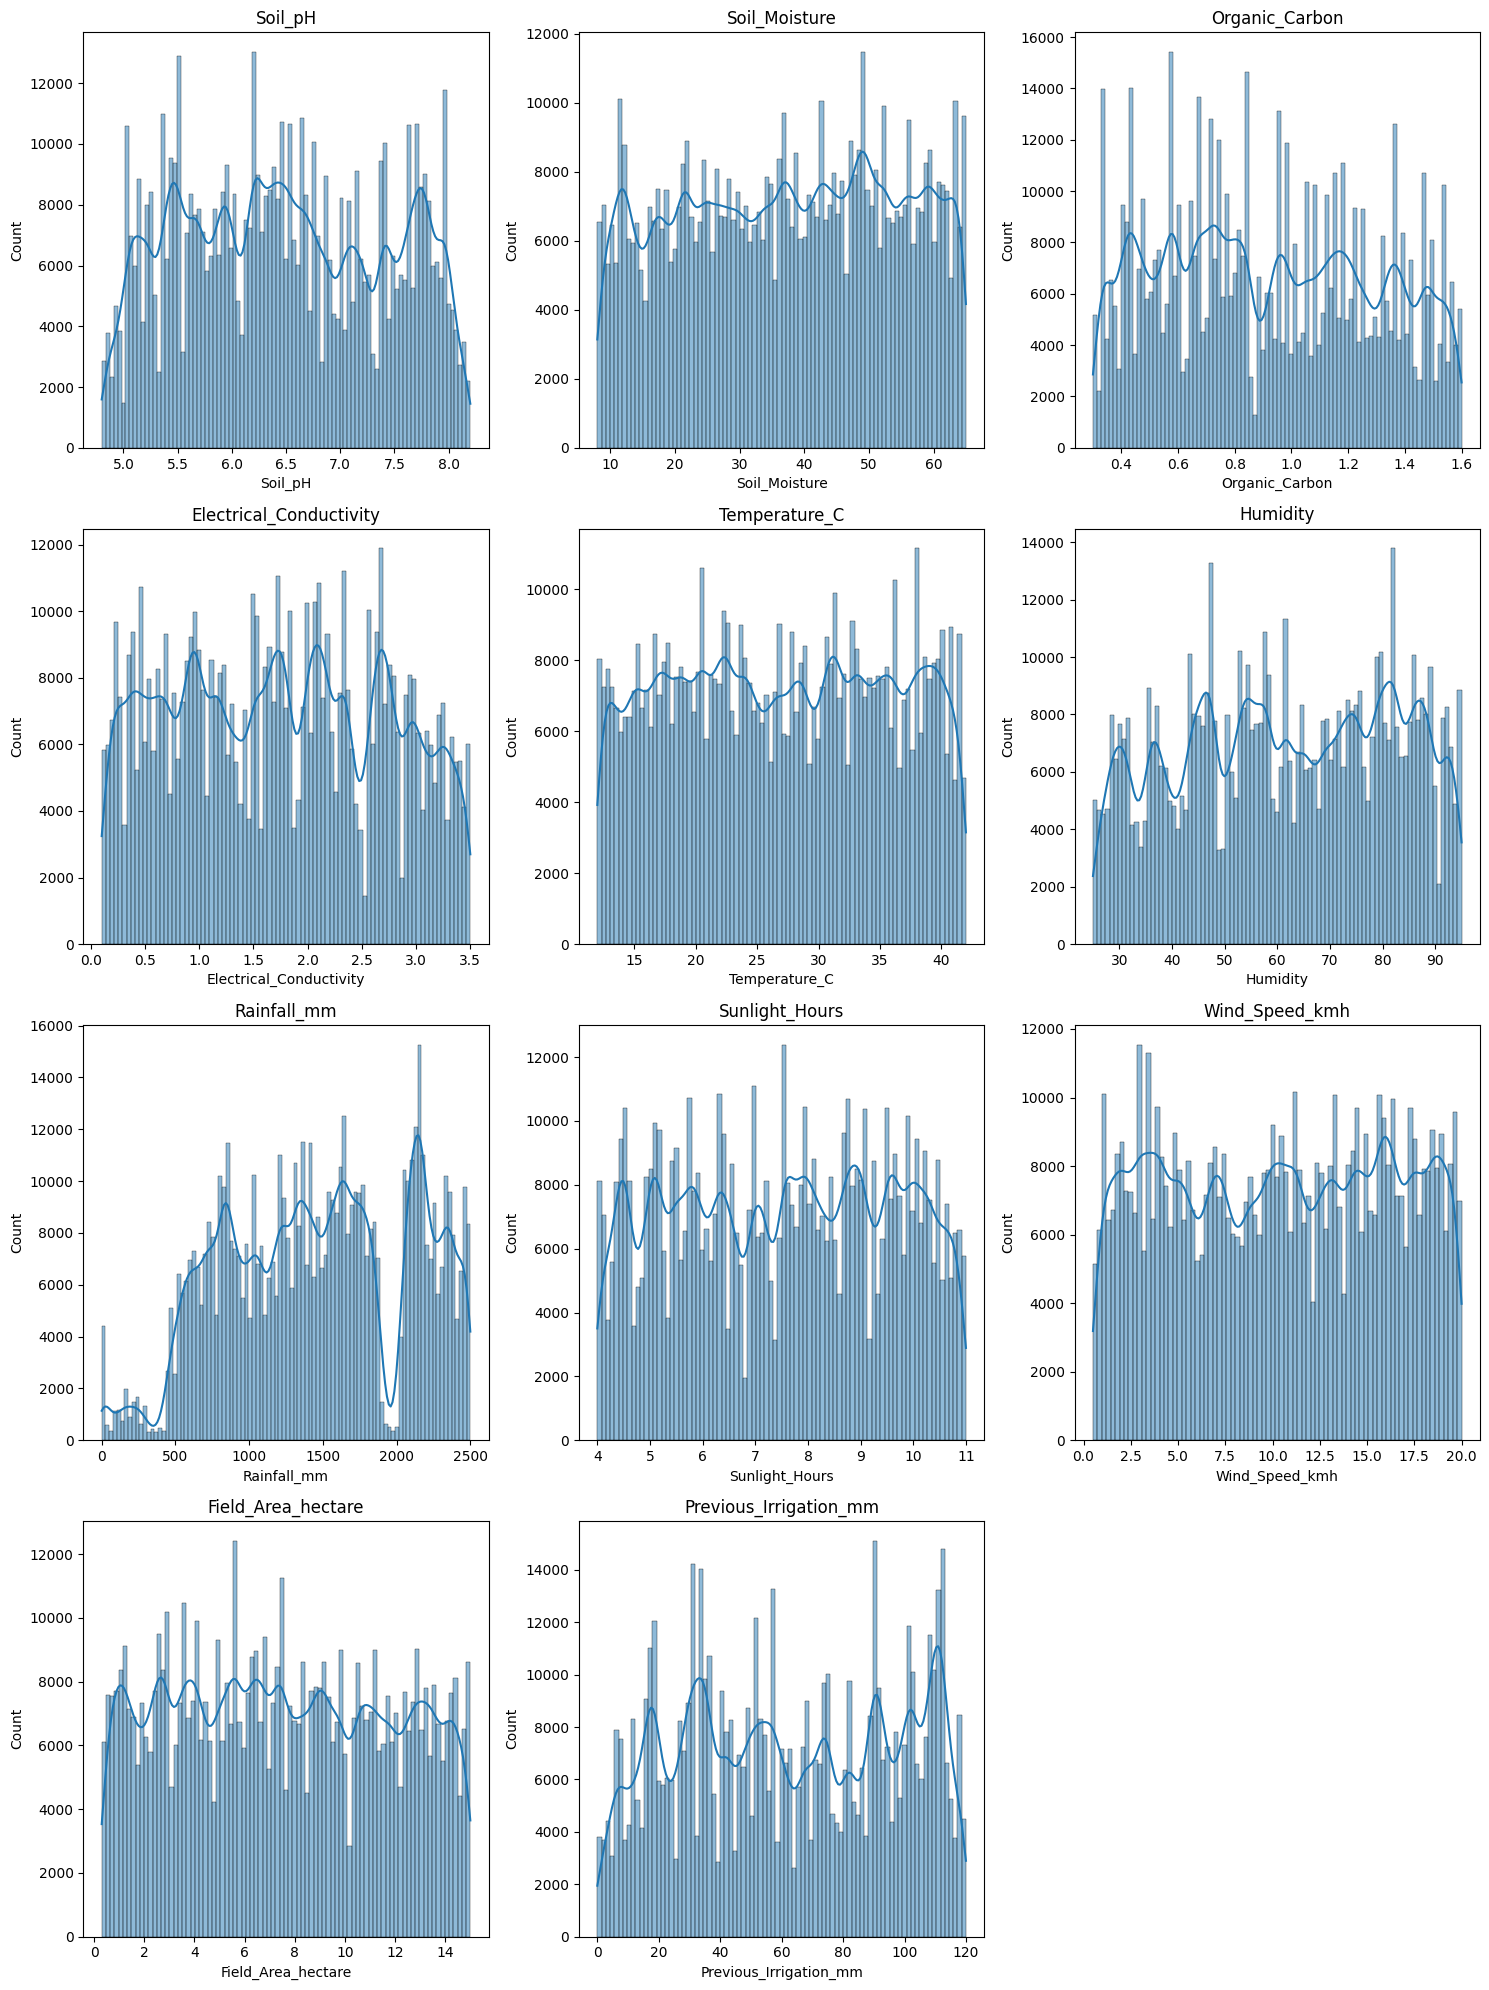

In [7]:
import seaborn as sns
import math

n_cols = 3
n_rows = math.ceil(len(num_cols) / n_cols)

plt.figure(figsize=(15, 5 * n_rows))

for i, col in enumerate(num_cols, 1):
    plt.subplot(n_rows, n_cols, i)
    sns.histplot(X[col], kde=True)
    plt.title(col)

plt.tight_layout()
plt.show()

Most features show roughly uniform/flat distributions with high variance (spiky bars)

### Checking for outliers

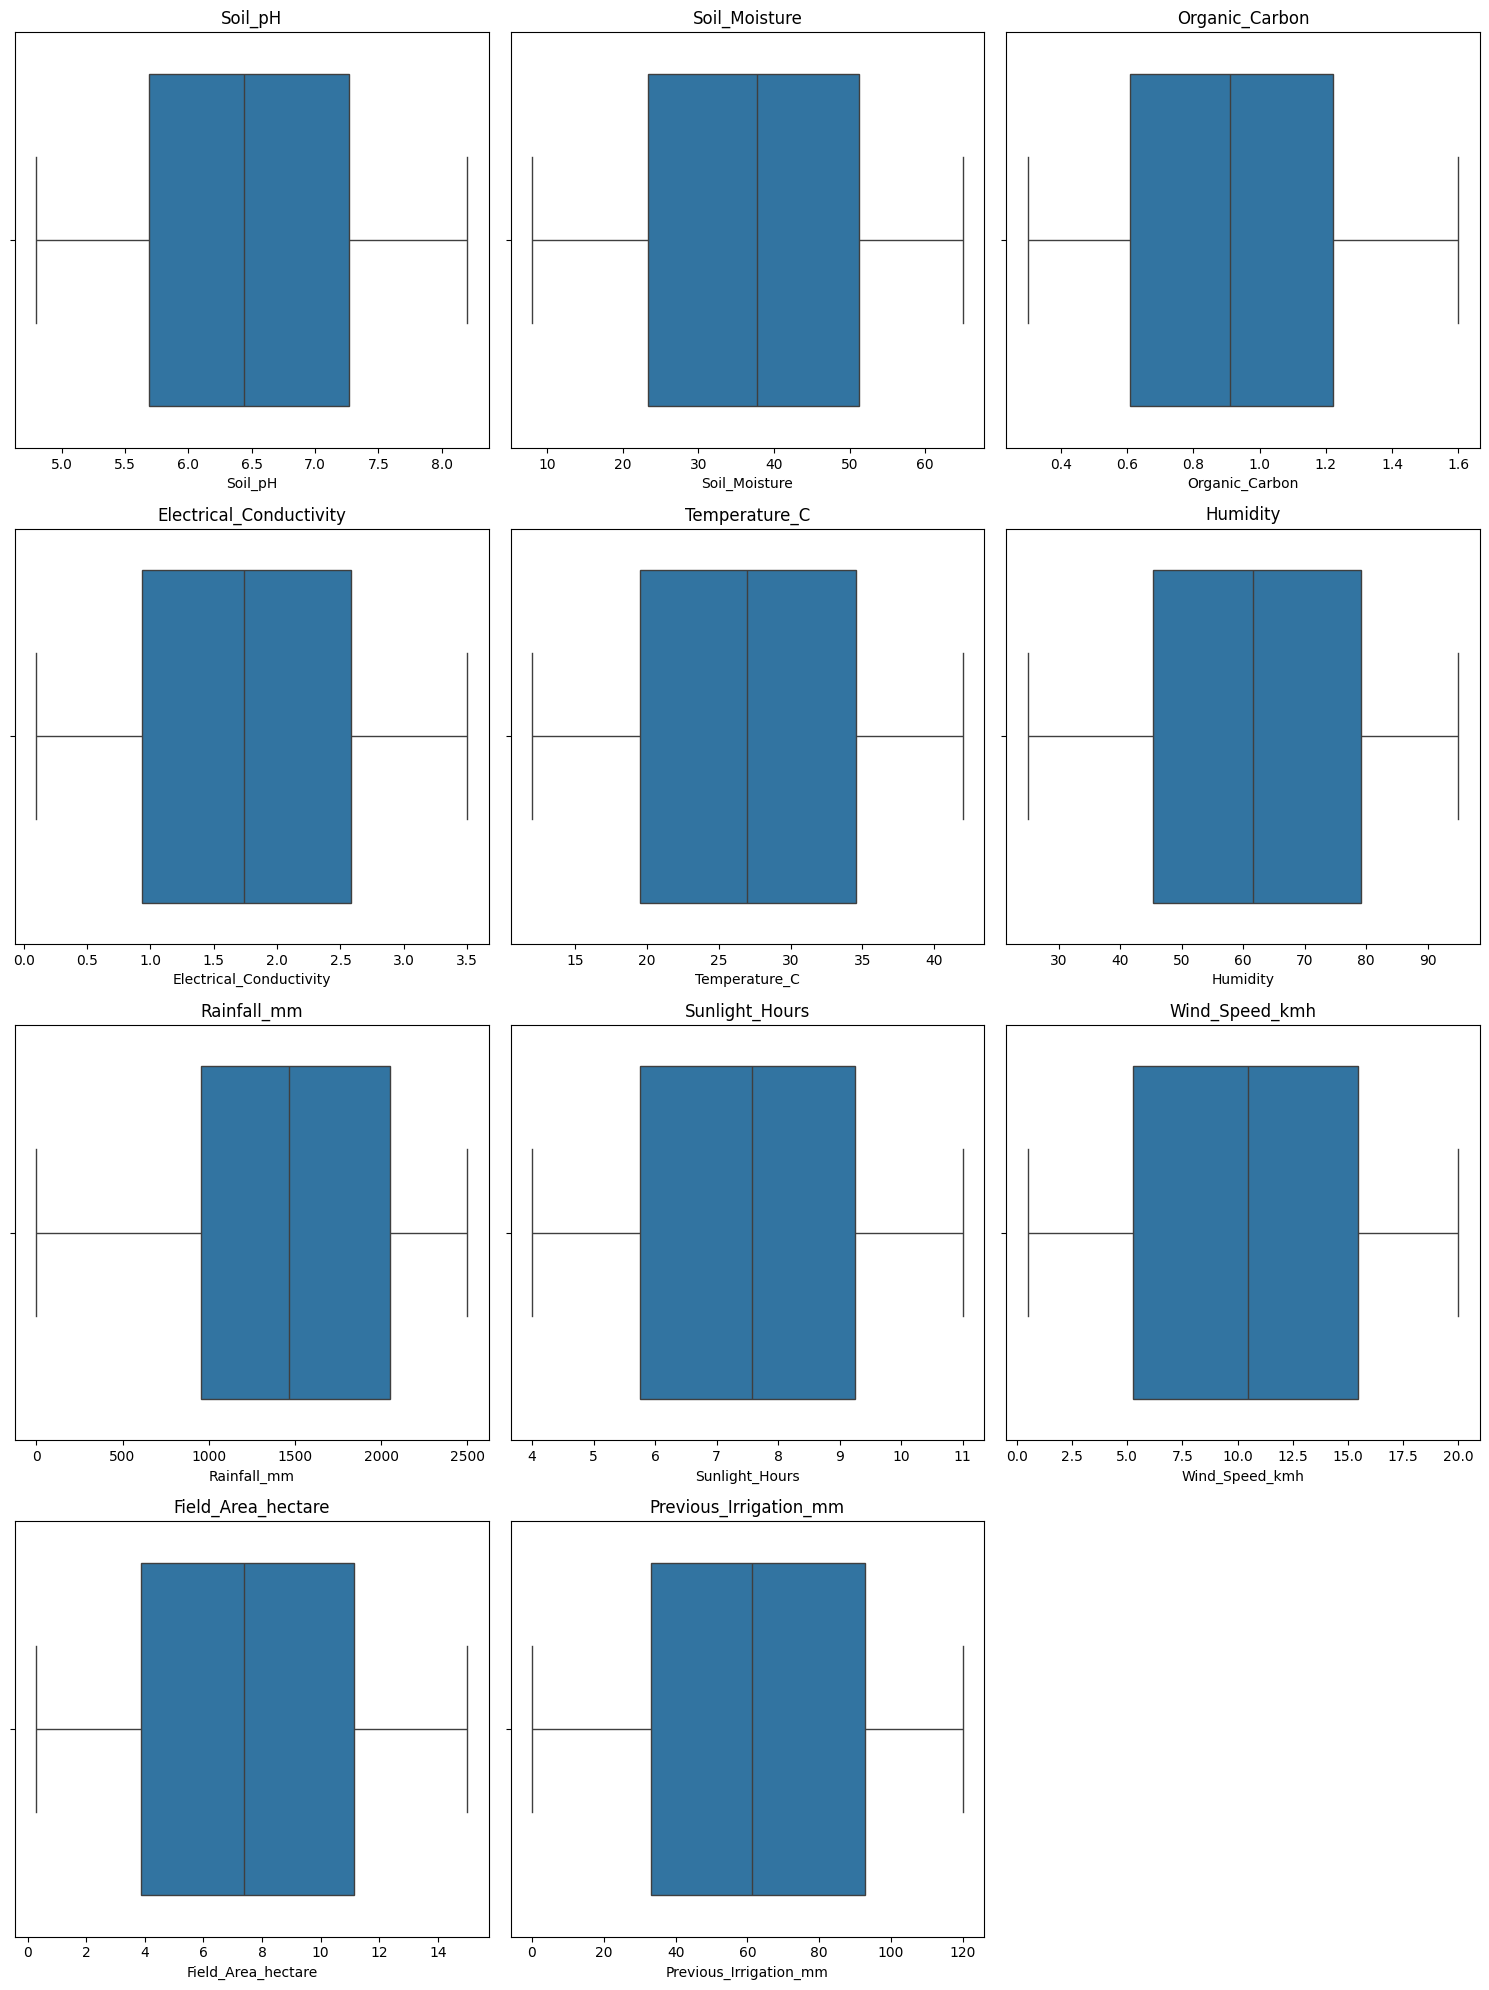

In [8]:
# box plots
plt.figure(figsize=(15, 5 * n_rows))

for i, col in enumerate(num_cols, 1):
    plt.subplot(n_rows, n_cols, i)
    sns.boxplot(x=X[col])
    plt.title(col)

plt.tight_layout()
plt.show()

* No significant outliers visible across any feature — whiskers are clean
* Most distributions are symmetric (median near box center)
* Rainfall_mm stands out with the widest spread

### Feature vs Target

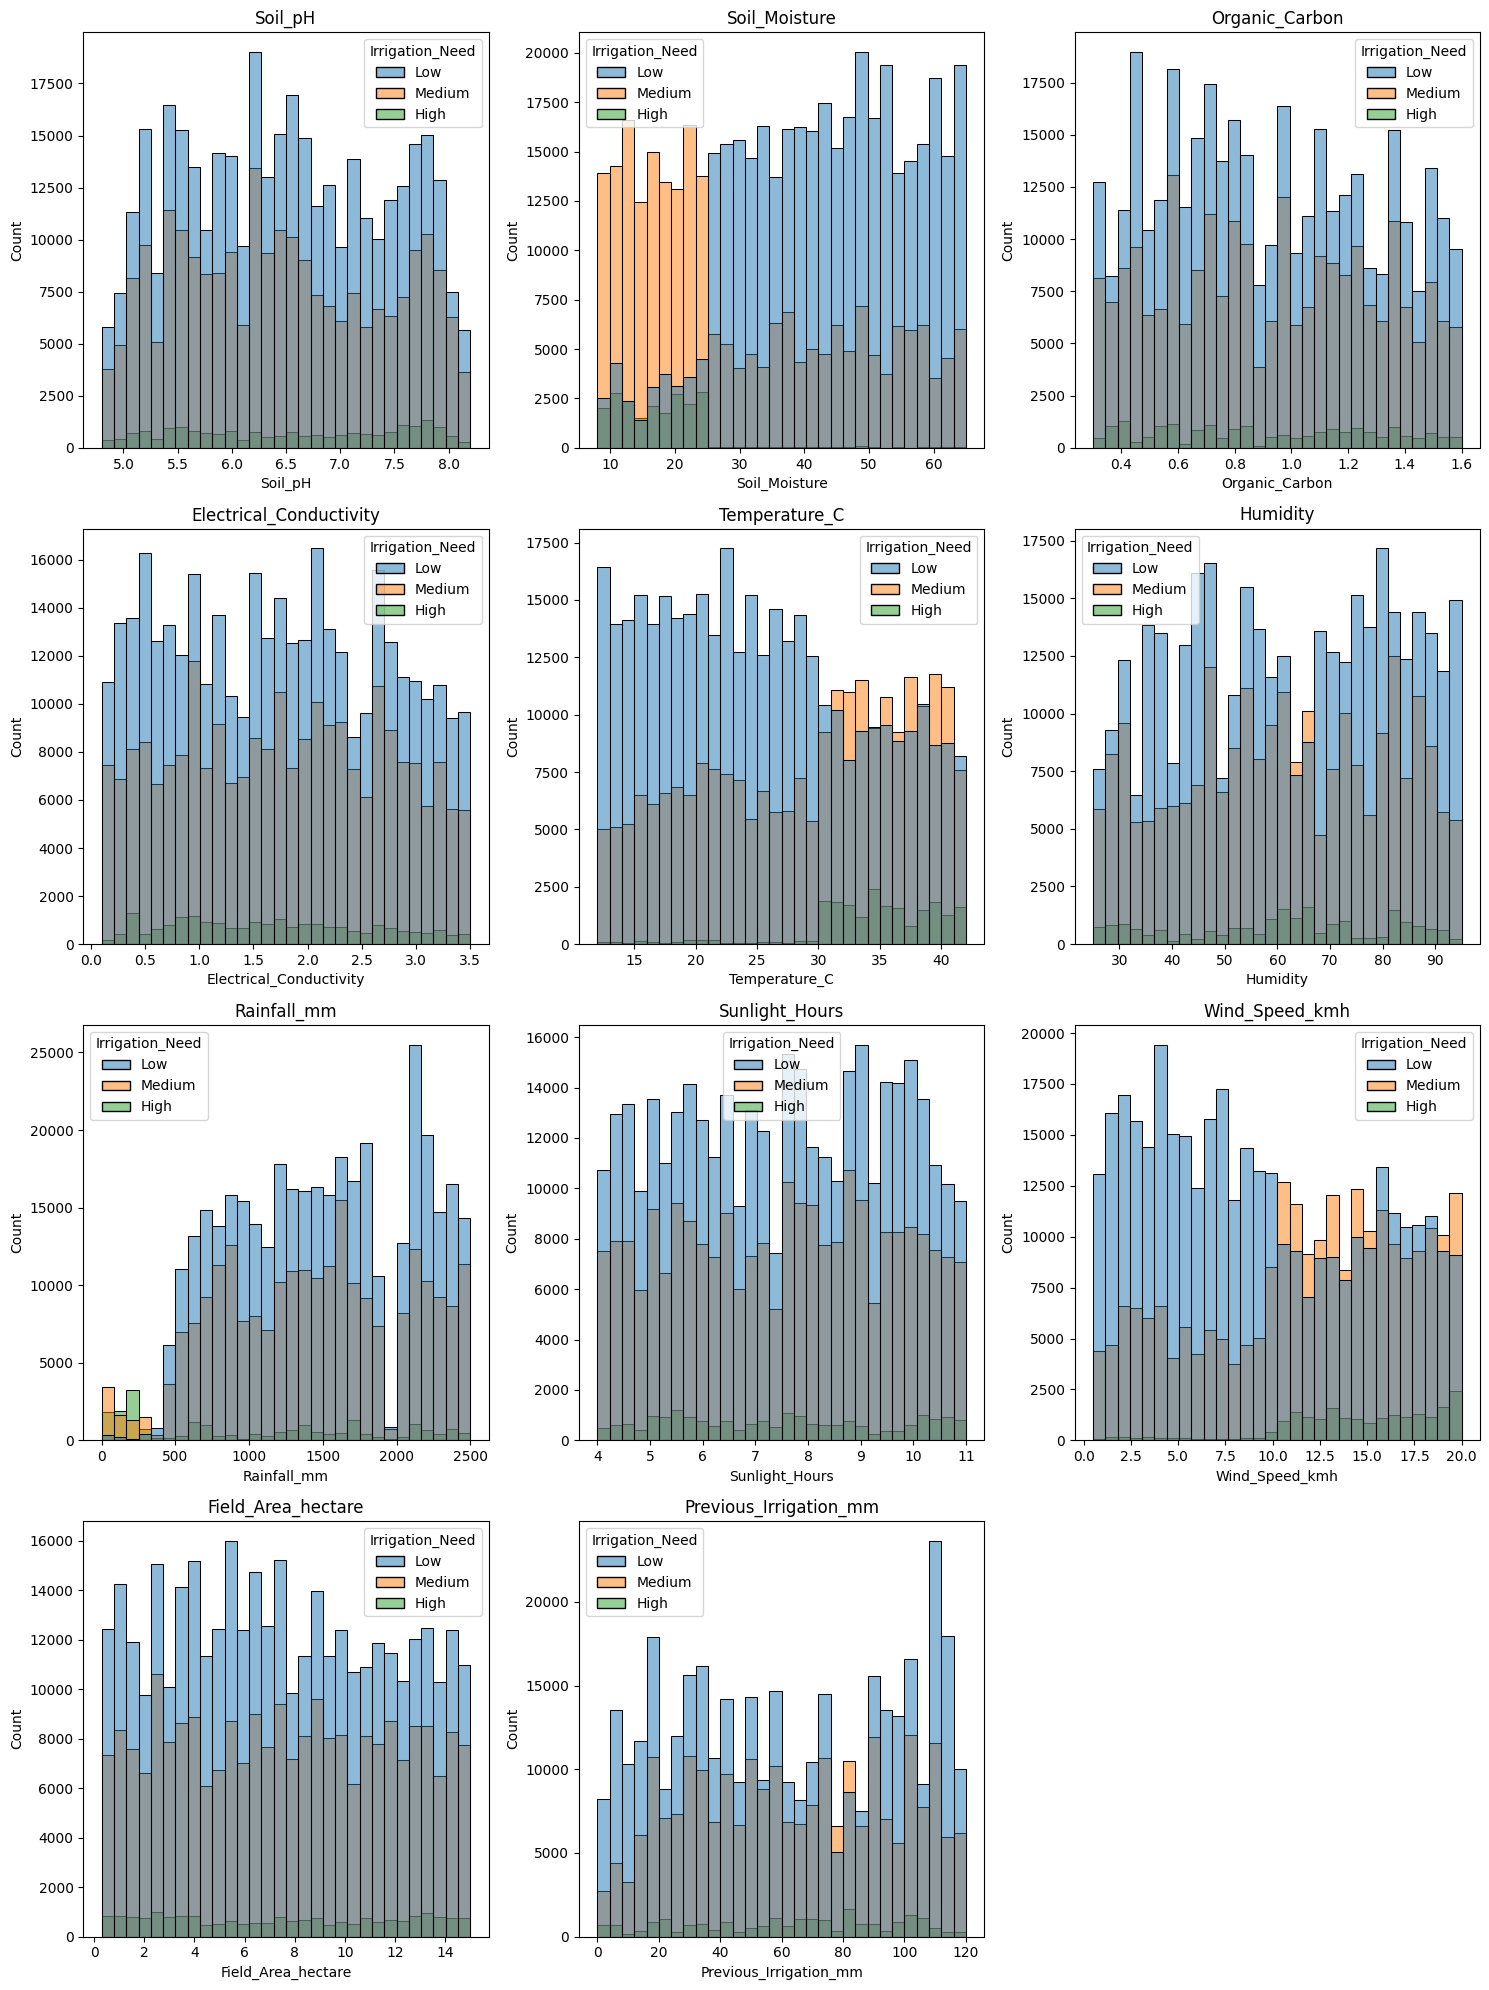

In [9]:
plt.figure(figsize=(15, 5 * n_rows))

for i, col in enumerate(num_cols, 1):
    plt.subplot(n_rows, n_cols, i)
    sns.histplot(data=train_df, x=col, hue=target, bins=30)
    plt.title(col)

plt.tight_layout()
plt.show()

* Soil_Moisture --> Strongest signal
  
        1. Low moisture (10–25) → dominated by Medium & High irrigation need (orange/green)
        2. High moisture (35+) → dominated by Low irrigation need (blue)
        3. Clear, logical inverse relationship — most predictive feature

* Temperature_C 

        1. Higher temperatures (35–42°C) → more Medium/High irrigation need
        2. Lower temps → mostly Low need
        3. Strong positive relationship

* Rainfall_mm
        
        1. Very low rainfall (0–200mm) → Medium/High irrigation need spikes
        2. Higher rainfall → predominantly Low need
        3. Logical and strong signal

* Humidity

        1. Lower humidity (~30–45%) → more Medium/High need
        2. Higher humidity → mostly Low need

* Wind_Speed_kmh

        1. Higher wind speeds (10–20) → slight increase in Medium/High need
        2. Moderate signal

* Previous_Irrigation_mm

        1. Around 80–90mm → small Medium spike visible
        2. Relatively weak signal overall

  

* Weak/No Signal Features:

Soil_pH, Organic_Carbon, Electrical_Conductivity, Field_Area, Sunlight_Hours — mostly dominated by Low across all bins, suggesting limited predictive power for irrigation need

## Categorical Feature Analysis

### Count Plots:

Soil_Type
Sandy    166509
Clay     158470
Loamy    156455
Silt     148566
Name: count, dtype: int64


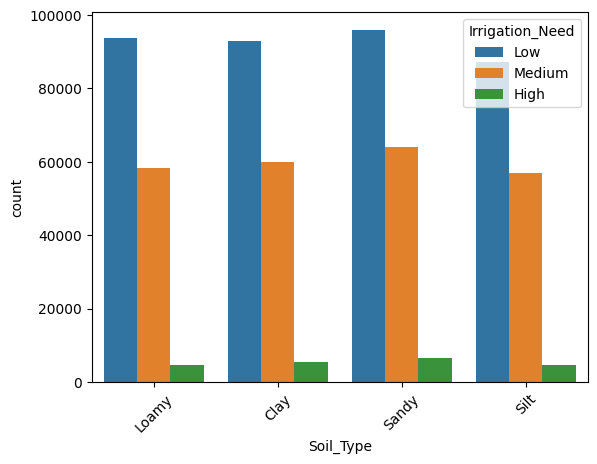

Crop_Type
Sugarcane    108910
Rice         106697
Cotton       104645
Maize        104274
Wheat        103005
Potato       102469
Name: count, dtype: int64


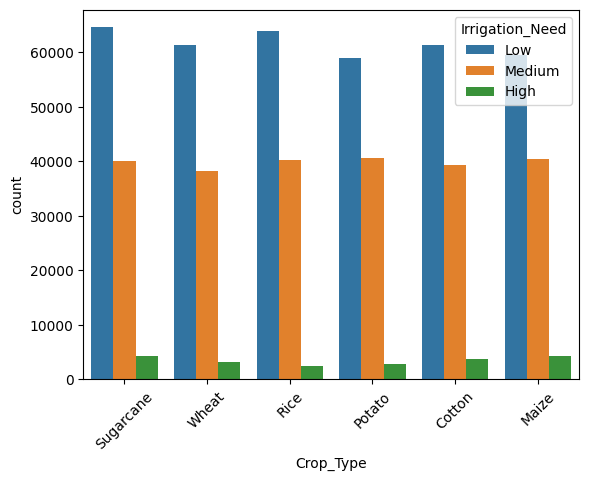

Crop_Growth_Stage
Harvest       167689
Flowering     157563
Vegetative    157246
Sowing        147502
Name: count, dtype: int64


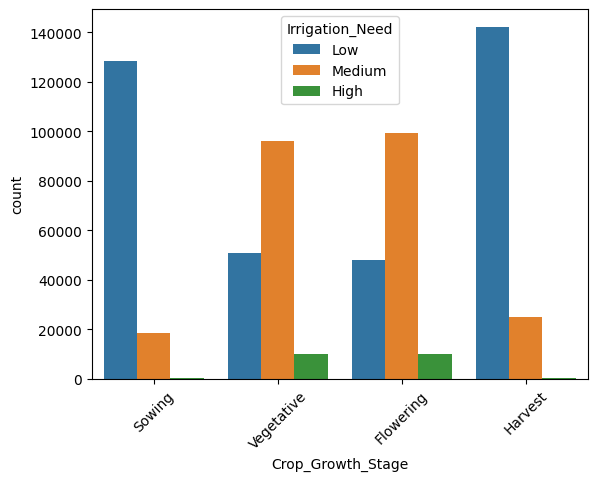

Season
Kharif    216561
Rabi      208033
Zaid      205406
Name: count, dtype: int64


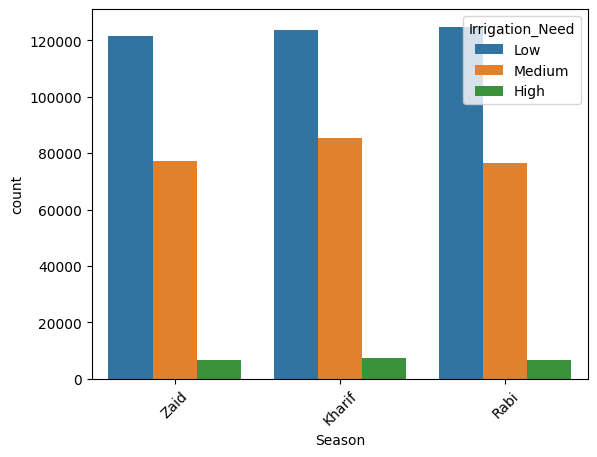

Irrigation_Type
Canal        161901
Sprinkler    161400
Rainfed      155607
Drip         151092
Name: count, dtype: int64


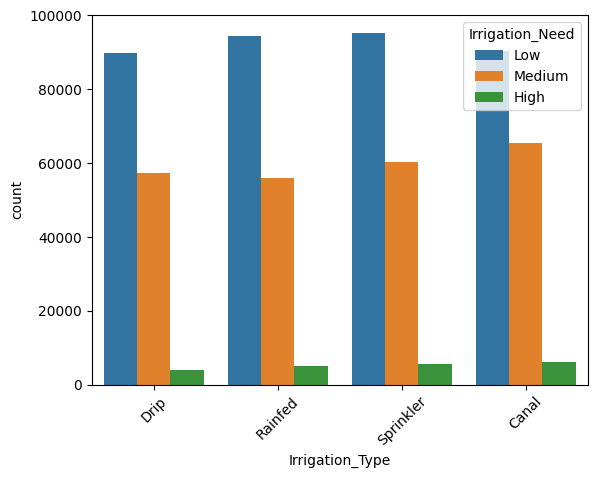

Water_Source
Reservoir      162994
River          159819
Groundwater    154155
Rainwater      153032
Name: count, dtype: int64


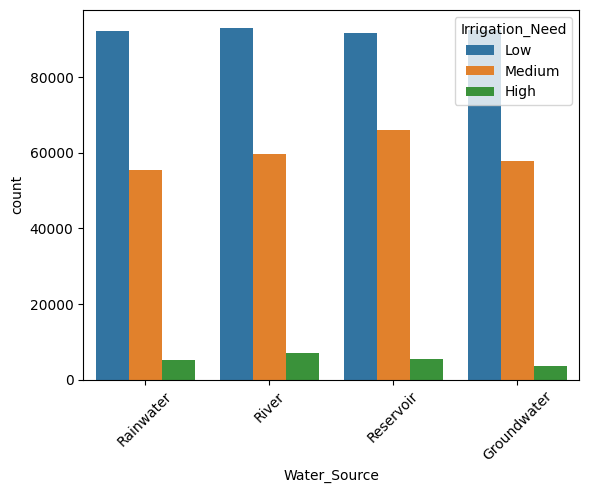

Mulching_Used
No     316453
Yes    313547
Name: count, dtype: int64


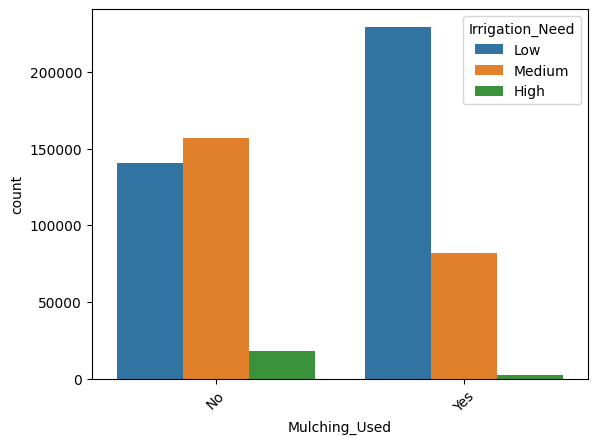

Region
South      134809
West       131189
East       126163
Central    123712
North      114127
Name: count, dtype: int64


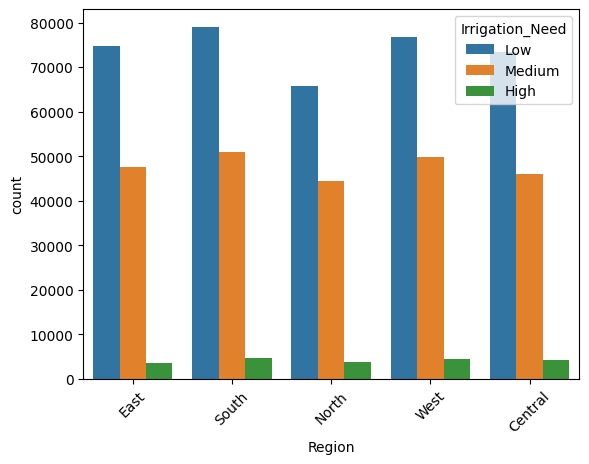

In [11]:
for col in cat_cols:
    print(X[col].value_counts())
    sns.countplot(data=train_df, x=col, hue=target)
    plt.xticks(rotation=45)
    plt.show()

Only promising feature I see is **crop_growth_stage**, other categorical features show strong signals.
* The ratio of Low:Medium:High is almost identical across all categories
* The bars are proportionally near-identical — the pattern doesn't meaningfully change across categories.
* A strong signal would show one type heavily skewed toward High or another toward Low.

A tree based model would work well, we might be able to see some great splits on this type of data.

## Correlation Analysis:

<Axes: >

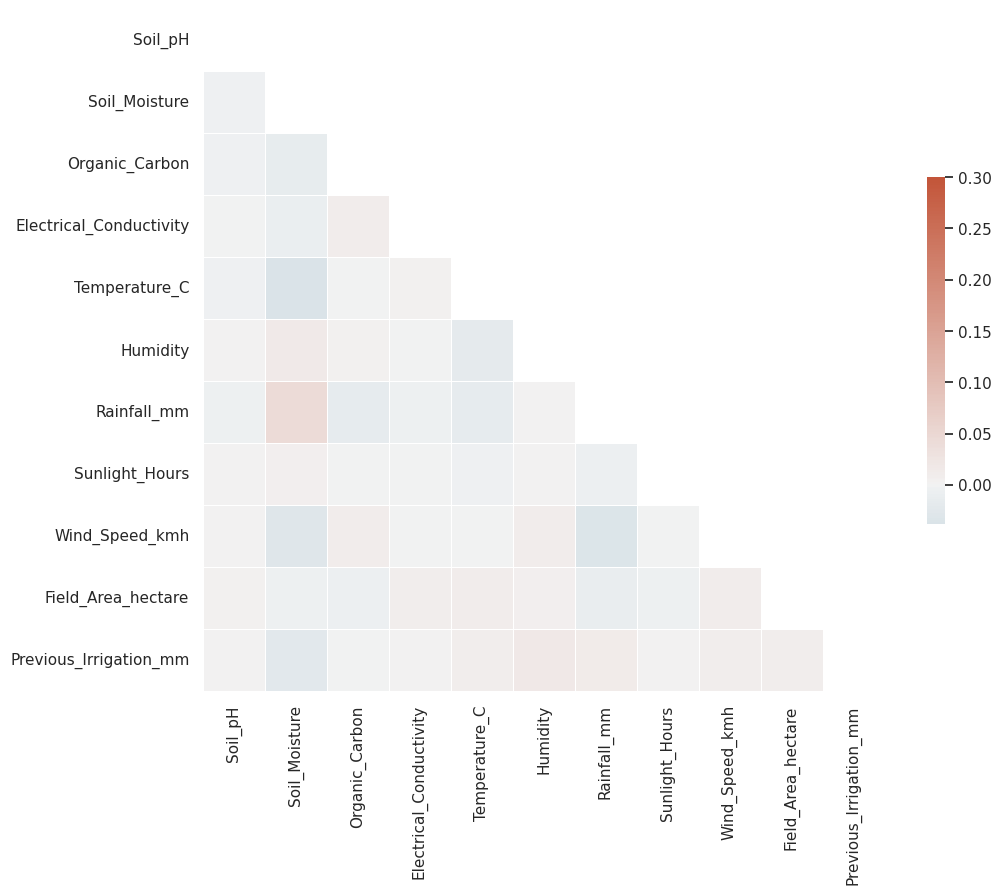

In [18]:
import numpy as np

corr = train_df[num_cols].corr()

sns.set_theme(style="white")
mask = np.triu(np.ones_like(corr, dtype=bool))
f, ax = plt.subplots(figsize=(11, 9))
cmap = sns.diverging_palette(230, 20, as_cmap=True)

# Drawing the heatmap with the mask and correct aspect ratio
sns.heatmap(corr, mask=mask, cmap=cmap, vmax=.3, center=0,
            square=True, linewidths=.5, cbar_kws={"shrink": .5})

The entire heatmap sits in the 0.00–0.30 range with most cells barely visible that is Near-Zero Multicollinearity

## Train vs Test Distributions

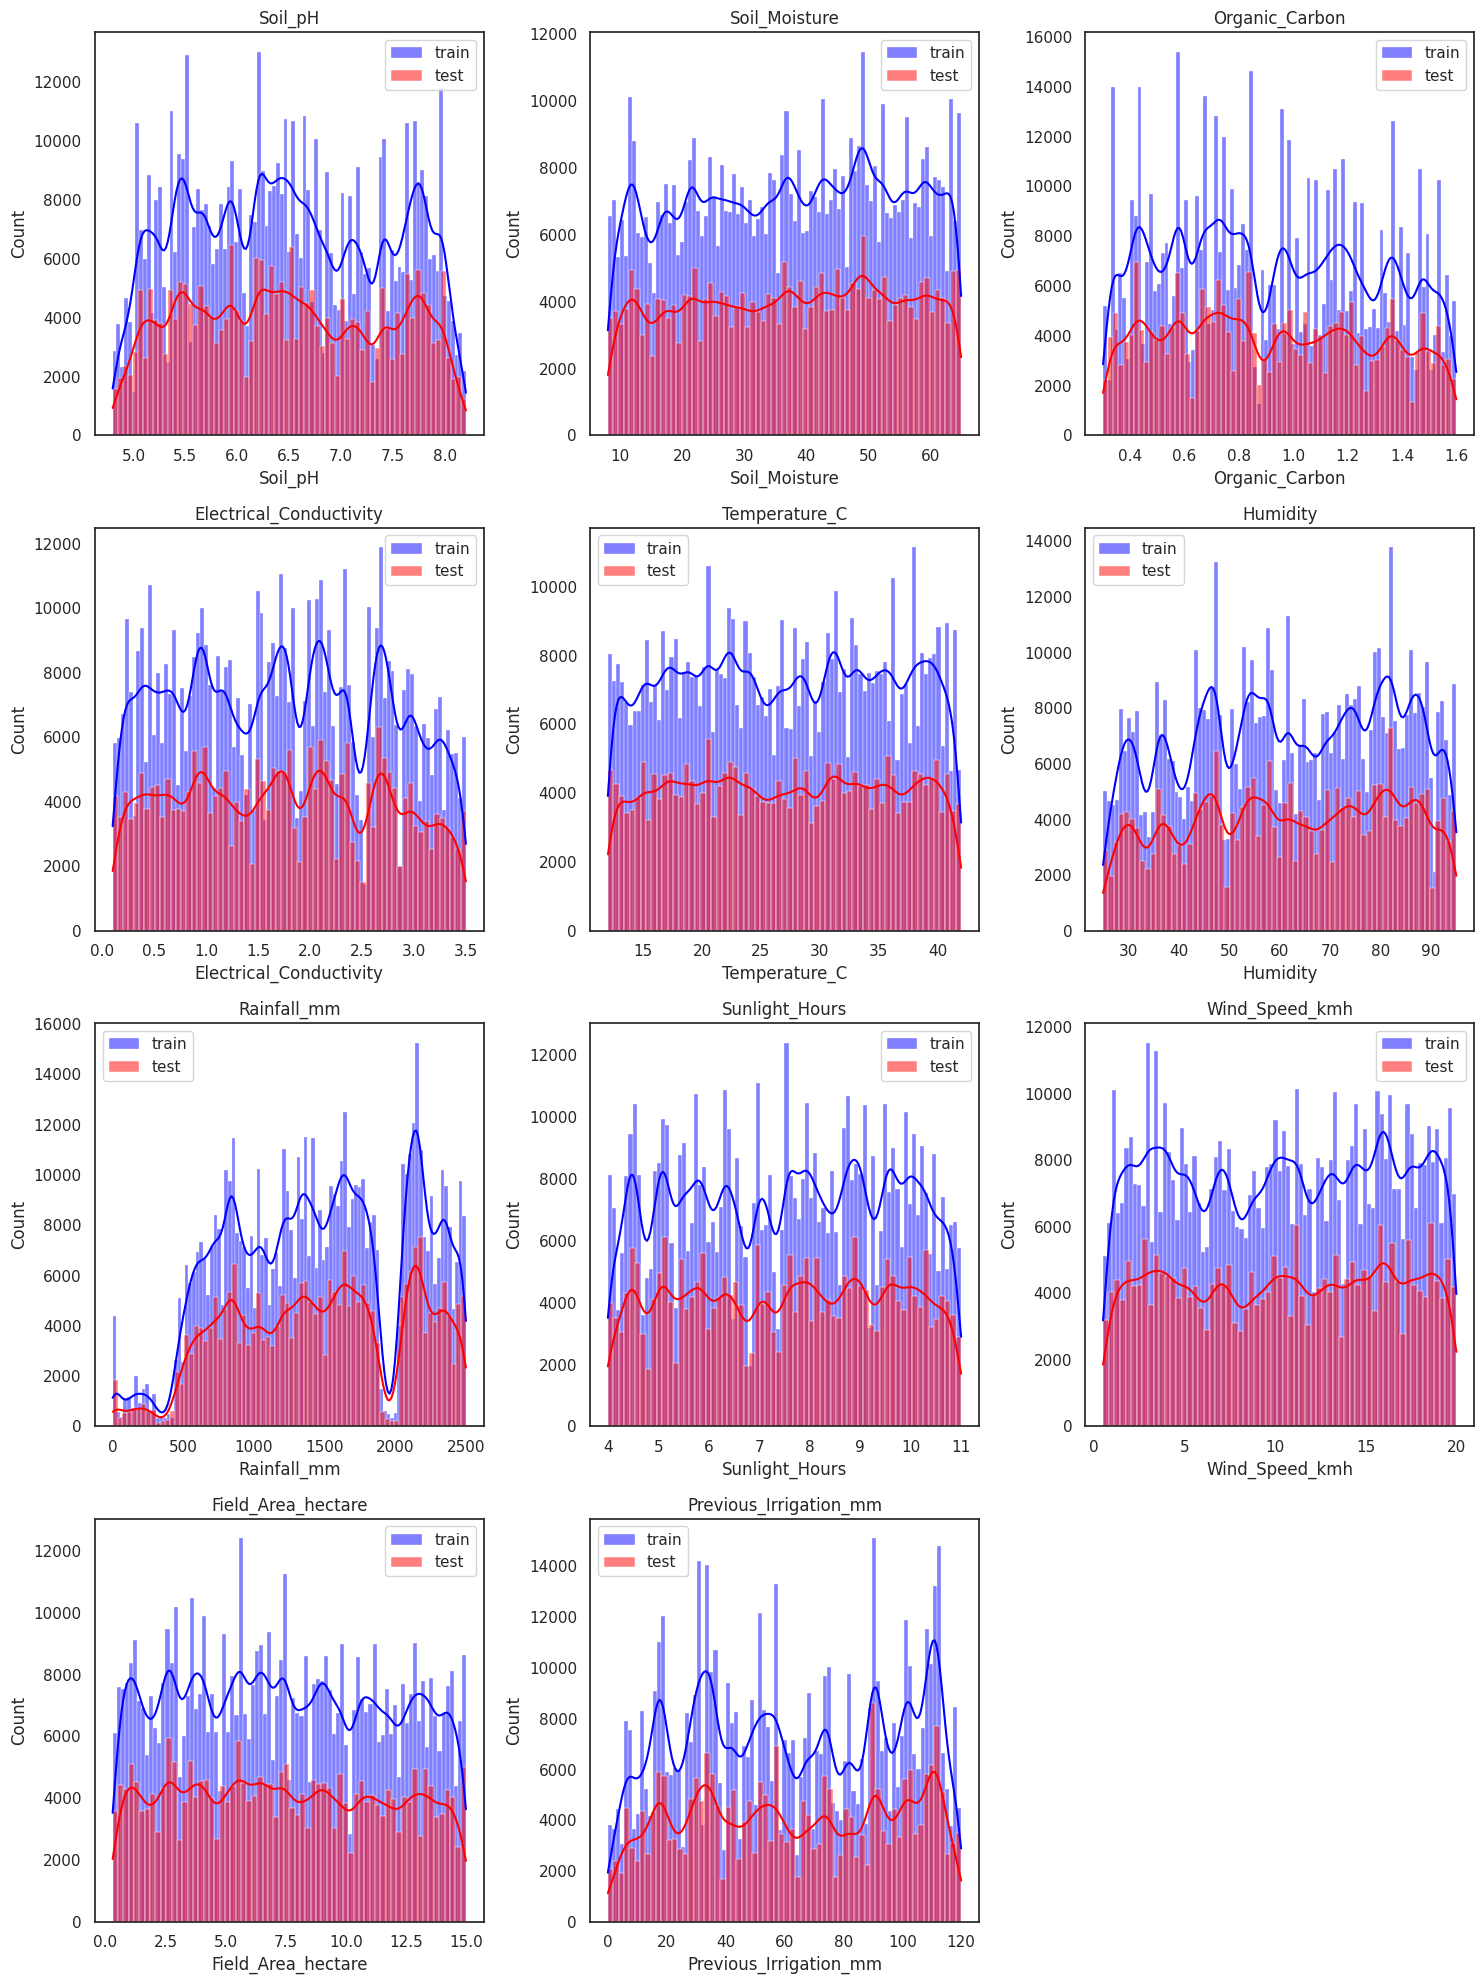

In [23]:
plt.figure(figsize=(15, 5 * n_rows))

for i, col in enumerate(num_cols, 1):
    plt.subplot(n_rows, n_cols, i)
    sns.histplot(train_df[col], color="blue", label="train", kde=True)
    sns.histplot(test_df[col], color="red", label="test", kde=True)
    plt.legend()
    plt.title(col)

plt.tight_layout()
plt.show()

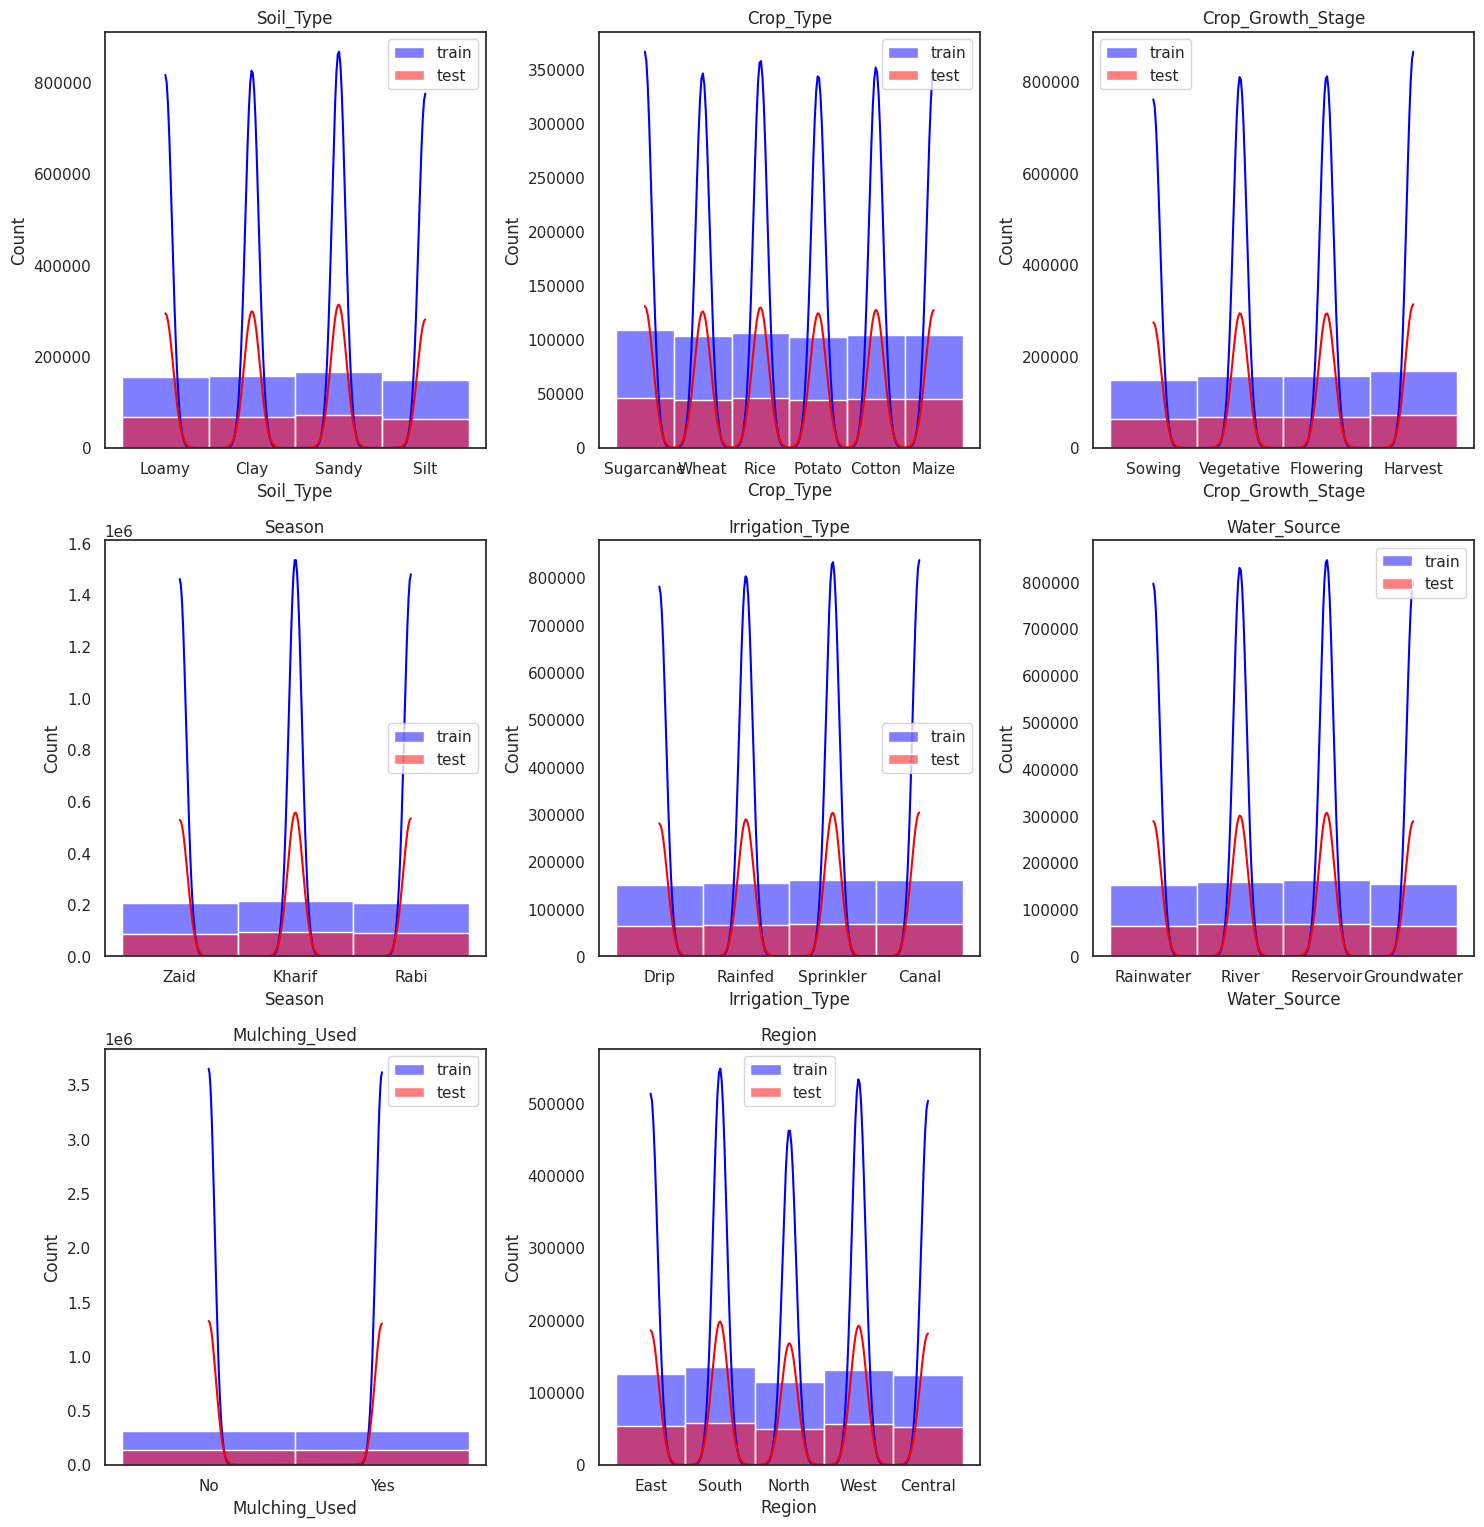

In [24]:
plt.figure(figsize=(15, 5 * n_rows))

for i, col in enumerate(cat_cols, 1):
    plt.subplot(n_rows, n_cols, i)
    sns.histplot(train_df[col], color="blue", label="train", kde=True)
    sns.histplot(test_df[col], color="red", label="test", kde=True)
    plt.legend()
    plt.title(col)

plt.tight_layout()
plt.show()

The distributions of the test and train data are similar

## Conclusion:

This is a clean, synthetic, large-scale multiclass classification dataset with severe class imbalance. The top 3 predictors are Soil_Moisture, Rainfall, and Temperature — all logically consistent with irrigation science. Categorical features and remaining numericals carry weak marginal signal but will contribute through feature interactions in tree-based models. Tree based models would perform well on such dataset.